# Credit Card Customer Default Analysis

This notebook explores customer balances, payment behavior, and repayment status. It compares a linear probability regression with logistic regression and generates default probabilities for the test customers.

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss, log_loss, mean_absolute_error, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Load the datasets

Update `DATA_DIR` if the CSV files are stored elsewhere.

In [13]:
DATA_DIR = Path.cwd() / 'inter-uni-datathon-stream-1-credit-card-clients'
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'Missing training values: {train.isna().sum().sum()}')
print(f'Default rate: {train.default.mean():.2%}')
train.head()

Train shape: (24000, 25)
Test shape:  (6000, 24)
Missing training values: 0
Default rate: 22.12%


,client_id,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,CC_0000F52C3717,50000,2,1,2,26,1,2,0,0,...,39475,40187,40992,2200,1962,1562,1500,1474,2300,0
1,CC_0008C4E44BB9,150000,2,1,2,26,-1,-1,-1,0,...,18400,1527,1527,0,18600,0,1527,0,0,0
2,CC_000B4B1BEDF6,450000,2,2,1,38,-2,-2,-2,-2,...,17255,17515,0,15008,1200,5255,4566,0,3648,0
3,CC_000D492CE7AD,230000,2,2,2,30,0,0,0,0,...,108826,100862,92481,6000,6000,4000,4000,3500,4000,0
4,CC_000DCFA992C4,160000,2,2,2,34,-1,-1,-1,-1,...,13780,12297,12752,24000,8000,13780,12300,12752,6000,0


## 2. Engineer interpretable customer metrics

The engineered fields describe average balances, total payments, payment-to-balance behavior, credit utilization, and delinquency history.

In [14]:
def add_customer_metrics(data):
    result = data.copy()
    bill_columns = [f'BILL_AMT{month}' for month in range(1, 7)]
    payment_columns = [f'PAY_AMT{month}' for month in range(1, 7)]
    status_columns = ['PAY_0'] + [f'PAY_{month}' for month in range(2, 7)]
    result['average_bill_balance'] = result[bill_columns].mean(axis=1)
    result['average_payment'] = result[payment_columns].mean(axis=1)
    result['total_bill_balance'] = result[bill_columns].sum(axis=1)
    result['total_payment'] = result[payment_columns].sum(axis=1)
    result['payment_to_bill_ratio'] = result['total_payment'] / (result['total_bill_balance'].abs() + 1)
    result['credit_utilization'] = result['average_bill_balance'] / (result['LIMIT_BAL'] + 1)
    result['maximum_delinquency'] = result[status_columns].max(axis=1)
    result['delinquent_months'] = (result[status_columns] > 0).sum(axis=1)
    return result

train = add_customer_metrics(train)
test = add_customer_metrics(test)
status_summary = train.groupby('default')[['average_bill_balance', 'average_payment', 'credit_utilization', 'delinquent_months']].mean().round(2)
status_summary

,average_bill_balance,average_payment,credit_utilization,delinquent_months
default,,,,
0,45005.55,5829.58,0.35,0.50
1,44446.56,3356.35,0.45,2.01


## 3. Visualise customer balances and repayment behaviour

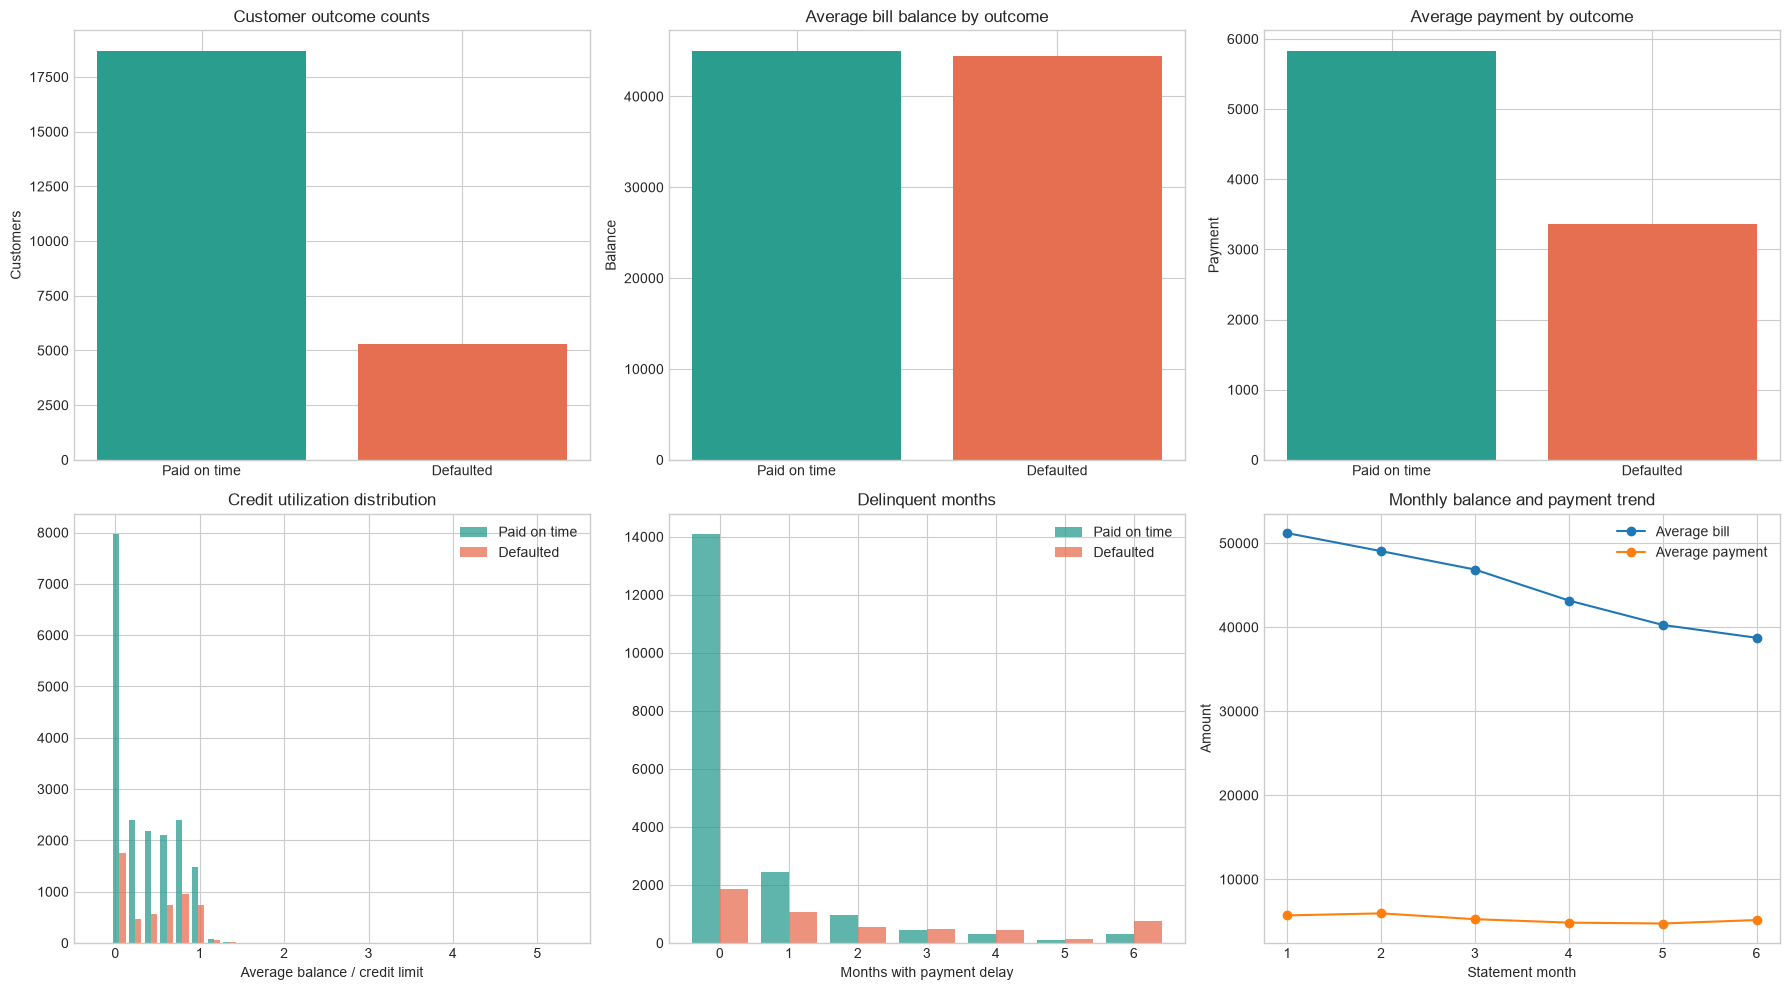

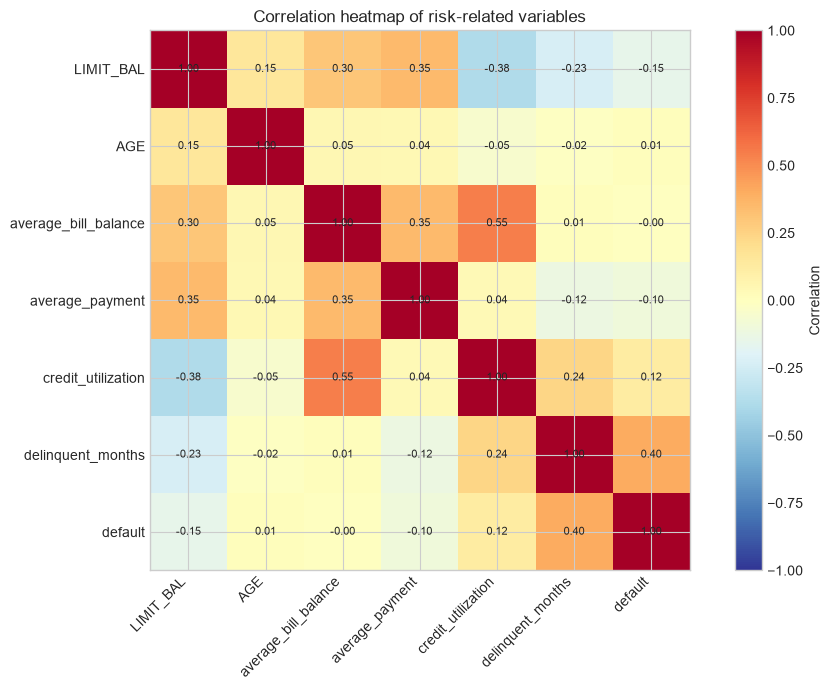

PyTorch tensor summary:
              Average bill  Average payment  Utilization  Delinquent months
Paid on time  45005.550781      5829.580078         0.35               0.50
Defaulted     44446.558594      3356.350098         0.45               2.01


In [15]:
import matplotlib.pyplot as plt
import torch

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

default_counts = train['default'].value_counts().sort_index()
axes[0, 0].bar(['Paid on time', 'Defaulted'], default_counts.values, color=['#2a9d8f', '#e76f51'])
axes[0, 0].set_title('Customer outcome counts')
axes[0, 0].set_ylabel('Customers')

status_means = train.groupby('default')[['average_bill_balance', 'average_payment']].mean()
axes[0, 1].bar(['Paid on time', 'Defaulted'], status_means['average_bill_balance'], color=['#2a9d8f', '#e76f51'])
axes[0, 1].set_title('Average bill balance by outcome')
axes[0, 1].set_ylabel('Balance')

axes[0, 2].bar(['Paid on time', 'Defaulted'], status_means['average_payment'], color=['#2a9d8f', '#e76f51'])
axes[0, 2].set_title('Average payment by outcome')
axes[0, 2].set_ylabel('Payment')

axes[1, 0].hist([train.loc[train.default == 0, 'credit_utilization'], train.loc[train.default == 1, 'credit_utilization']], bins=30, label=['Paid on time', 'Defaulted'], color=['#2a9d8f', '#e76f51'], alpha=0.75)
axes[1, 0].set_title('Credit utilization distribution')
axes[1, 0].set_xlabel('Average balance / credit limit')
axes[1, 0].legend()

axes[1, 1].hist([train.loc[train.default == 0, 'delinquent_months'], train.loc[train.default == 1, 'delinquent_months']], bins=np.arange(-0.5, 7.5, 1), label=['Paid on time', 'Defaulted'], color=['#2a9d8f', '#e76f51'], alpha=0.75)
axes[1, 1].set_title('Delinquent months')
axes[1, 1].set_xlabel('Months with payment delay')
axes[1, 1].set_xticks(range(7))
axes[1, 1].legend()

monthly_bills = [train[f'BILL_AMT{month}'].mean() for month in range(1, 7)]
monthly_payments = [train[f'PAY_AMT{month}'].mean() for month in range(1, 7)]
axes[1, 2].plot(range(1, 7), monthly_bills, marker='o', label='Average bill')
axes[1, 2].plot(range(1, 7), monthly_payments, marker='o', label='Average payment')
axes[1, 2].set_title('Monthly balance and payment trend')
axes[1, 2].set_xlabel('Statement month')
axes[1, 2].set_ylabel('Amount')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

feature_columns_for_corr = ['LIMIT_BAL', 'AGE', 'average_bill_balance', 'average_payment', 'credit_utilization', 'delinquent_months', 'default']
correlation = train[feature_columns_for_corr].corr()
plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap='RdYlBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_columns_for_corr)), feature_columns_for_corr, rotation=45, ha='right')
plt.yticks(range(len(feature_columns_for_corr)), feature_columns_for_corr)
plt.title('Correlation heatmap of risk-related variables')
for row in range(len(feature_columns_for_corr)):
    for column in range(len(feature_columns_for_corr)):
        plt.text(column, row, f'{correlation.iloc[row, column]:.2f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

risk_features = train[['average_bill_balance', 'average_payment', 'credit_utilization', 'delinquent_months']].to_numpy(dtype=np.float32)
risk_tensor = torch.from_numpy(risk_features)
outcome_tensor = torch.from_numpy(train['default'].to_numpy(dtype=np.float32))
group_means = torch.stack([risk_tensor[outcome_tensor == outcome].mean(dim=0) for outcome in (0, 1)])
print('PyTorch tensor summary:')
print(pd.DataFrame(group_means.numpy(), index=['Paid on time', 'Defaulted'], columns=['Average bill', 'Average payment', 'Utilization', 'Delinquent months']).round(2))

- The dataset contains 24,000 training customers and the default rate is 22.12%, so the classes are imbalanced.
- Average bill balances are similar for customers who paid on time and customers who defaulted, so balance size alone does not explain default risk.
- Defaulted customers make much smaller average payments: about 3,356 versus 5,830 for customers who paid on time.
- Defaulted customers have higher average credit utilization: about 45% versus 35%.
- Payment delinquency is the clearest visual warning sign: defaulted customers average about 2.01 delinquent months versus 0.50 months for customers who paid on time.
- These patterns show association, not causation. The model should combine payment status, utilization, payment amounts, and historical balances rather than relying on one variable.

## 4. Prepare features and validation data

Categorical codes are one-hot encoded, while numeric features are standardized inside the scikit-learn pipeline. The split is stratified so the validation default rate matches the training distribution.

In [16]:
target = 'default'
id_column = 'client_id'
categorical_columns = ['SEX', 'EDUCATION', 'MARRIAGE'] + [f'PAY_{period}' for period in [0, 2, 3, 4, 5, 6]]
feature_columns = [column for column in train.columns if column not in {target, id_column}]
x = train[feature_columns]
y = train[target]
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

def make_pipeline(model):
    categorical = [column for column in categorical_columns if column in feature_columns]
    numeric = [column for column in feature_columns if column not in categorical]
    transformer = ColumnTransformer([
        ('numeric', StandardScaler(), numeric),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
    ])
    return Pipeline([('preprocess', transformer), ('model', model)])

## 5. Compare regression models

The linear probability model directly answers the requested linear-regression use case. Logistic regression is included as a classification comparison. For probability prediction, ROC-AUC, log loss, Brier score, and mean absolute error are more informative than accuracy alone.

In [20]:
def evaluate_model(name, model):
    model.fit(x_train, y_train)
    probabilities = np.clip(model.predict(x_valid), 0, 1)
    predictions = (probabilities >= 0.5).astype(int)
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_valid, probabilities),
        'Average precision': average_precision_score(y_valid, probabilities),
        'Log loss': log_loss(y_valid, probabilities, labels=[0, 1]),
        'Brier score': brier_score_loss(y_valid, probabilities),
        'Accuracy': accuracy_score(y_valid, predictions),
        'Mean absolute error': mean_absolute_error(y_valid, probabilities),
    }

model_comparison = pd.DataFrame([
    evaluate_model('Linear probability regression', make_pipeline(LinearRegression())),
    evaluate_model('Logistic regression comparison', make_pipeline(LogisticRegression(max_iter=2000))),
]).set_index('Model')

model_comparison.round(4)

,ROC-AUC,Average precision,Log loss,Brier score,Accuracy,Mean absolute error
Model,,,,,,
Linear probability regression,0.7583,0.5088,0.4903,0.1414,0.8096,0.2749
Logistic regression comparison,0.6438,0.3648,6.7732,0.1879,0.8121,0.1879


## 6. Fit the selected model and create the submission

The linear model is selected based on the supplied holdout results. Predictions are clipped to `[0, 1]` so they are valid default probabilities.

In [18]:
# Rebuild the pipeline if the earlier cell was not executed in this session.
if 'make_pipeline' not in globals():
    def make_pipeline(model):
        categorical = [column for column in categorical_columns if column in feature_columns]
        numeric = [column for column in feature_columns if column not in categorical]
        transformer = ColumnTransformer([
            ('numeric', StandardScaler(), numeric),
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
        ])
        return Pipeline([('preprocess', transformer), ('model', model)])

# Ensure the feature/model setup exists even if earlier cells were not executed
if 'categorical_columns' not in globals():
    categorical_columns = ['SEX', 'EDUCATION', 'MARRIAGE'] + [f'PAY_{period}' for period in [0, 2, 3, 4, 5, 6]]

if 'feature_columns' not in globals():
    feature_columns = [column for column in train.columns if column not in {'default', 'client_id'}]

if 'x' not in globals() or 'y' not in globals():
    x = train[feature_columns]
    y = train['default']

linear_model = make_pipeline(LinearRegression())
linear_model.fit(x, y)
test_probabilities = np.clip(linear_model.predict(test[feature_columns]), 0, 1)
submission = pd.DataFrame({
    'client_id': test['client_id'],
    'default_probability': test_probabilities,
})
submission.to_csv('submission.csv', index=False)
print(f'Wrote {len(submission):,} predictions to submission.csv')
print(f'Probability range: {submission.default_probability.min():.4f} to {submission.default_probability.max():.4f}')
submission.head()

Wrote 6,000 predictions to submission.csv
Probability range: 0.0000 to 1.0000


,client_id,default_probability
0,CC_0012A082B7B7,0.222044
1,CC_0012BC27DFB6,0.157631
2,CC_001563B2143D,0.166199
3,CC_001B46930B6F,0.117973
4,CC_001D771E1C9F,0.087280
